In [1]:
# Cell 1 - Project Title (Markdown)

# # TASK 2 - Unemployment Analysis with Python

# ## Objective
# Perform Exploratory Data Analysis (EDA) on unemployment data in India and understand regional and temporal trends, especially the impact of COVID-19.

# ### Technologies Used
# - Python
# - Pandas
# - Matplotlib
# - Seaborn
# - Jupyter Notebook

In [2]:
# Cell 2 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [4]:
# Cell 3 - Load Dataset

import pandas as pd

df = pd.read_csv(r"C:\Users\bts\OneDrive\OIBSIP\Task 2\Unemployment in India.csv")
print(df.columns.tolist())


['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [5]:
# Cell 4 - Display Dataset

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
# Cell 5 - Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 768
Columns : 7


In [7]:
# Cell 6 - Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [8]:
# Cell 7 - Missing Values

df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [14]:
# Cell 8 - Rename Columns

df.columns

# Rename them

df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [15]:
# Cell 9 - Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 58.0 KB


C:\Users\bts\AppData\Local\Temp\ipykernel_20192\2860411974.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [16]:
# Cell 10 - Clean Missing Values

df = df.dropna()

df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [17]:
# Markdown

# The dataset has been cleaned by removing missing values and converting the Date column into datetime format for time-series analysis.

In [19]:
# Cell 11 - Statistical Summary

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [20]:
# Cell 12 - Unique States

print(df['Region'].nunique())

df['Region'].unique()

28


<ArrowStringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

In [21]:
# Markdown

# The dataset contains unemployment information from multiple Indian states and union territories.



In [22]:
# Cell 13 - Region-wise Average Unemployment

region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()
region_avg

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

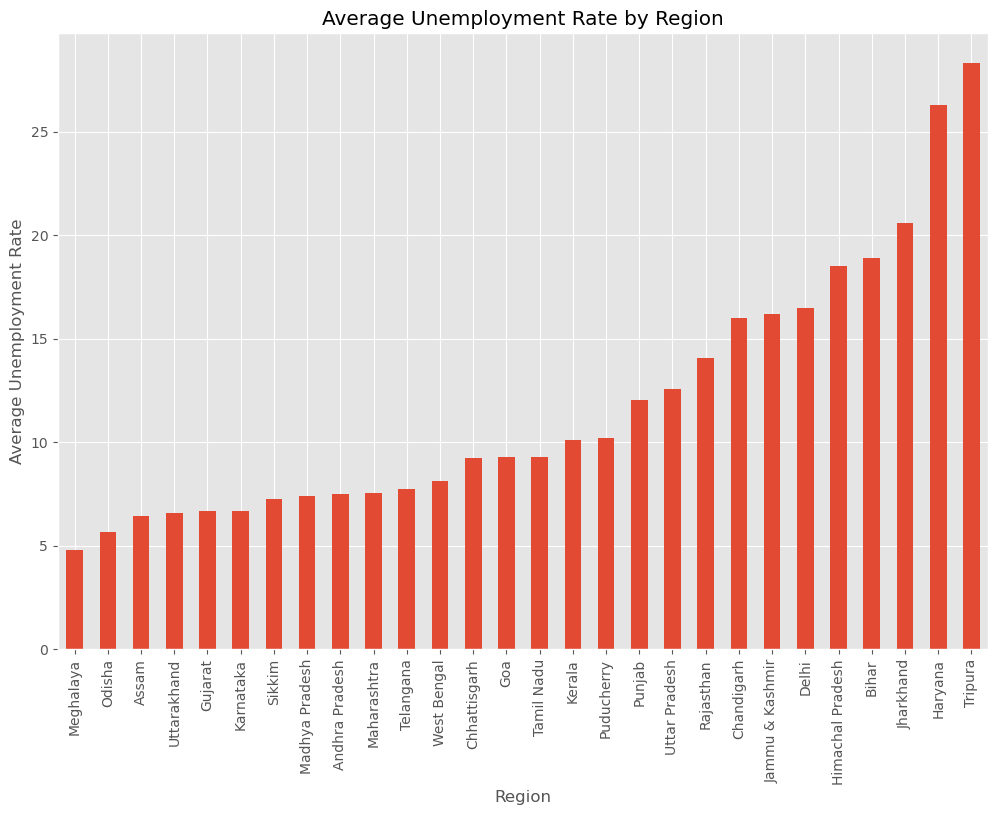

In [23]:
# Cell 14 - Bar Plot

plt.figure(figsize=(12,8))

region_avg.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate")

plt.xticks(rotation=90)

plt.show()

In [25]:
# # Markdown

# Observation:

# Some regions consistently report higher unemployment than others.
# This variation may arise from industrial development, urbanization, seasonal employment, and economic conditions.

In [26]:
# Cell 15 - Monthly Trend

monthly = df.groupby(df['Date'].dt.to_period("M"))["Estimated Unemployment Rate (%)"].mean()

monthly

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

In [28]:
# Cell 16 - Convert Index

monthly.index = monthly.index.astype(str)

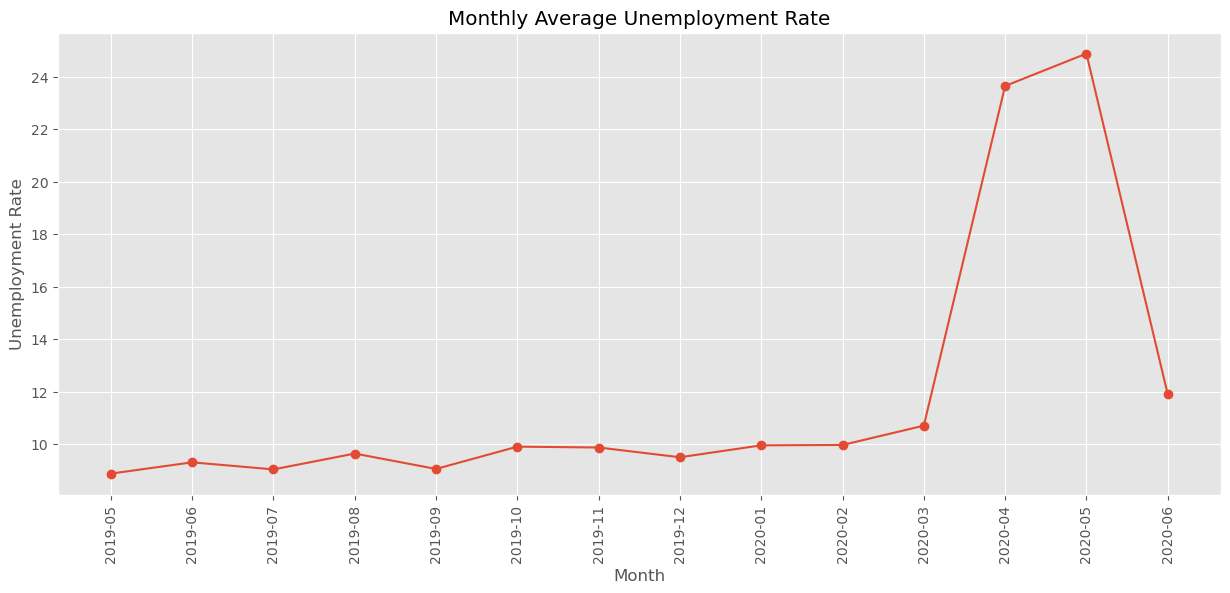

In [29]:
# Cell 17 - Line Chart

plt.figure(figsize=(15,6))

plt.plot(monthly.index,
         monthly.values,
         marker='o')

plt.xticks(rotation=90)

plt.title("Monthly Average Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Unemployment Rate")

plt.show()

In [30]:
# Markdown

# Observation:

# The unemployment rate fluctuates across months.
# A sharp rise is expected during the COVID-19 lockdown period.

In [31]:
# Cell 18 - Select Major States

major_states = [
    "Maharashtra",
    "Delhi",
    "Tamil Nadu"
]

state_df = df[df["Region"].isin(major_states)]

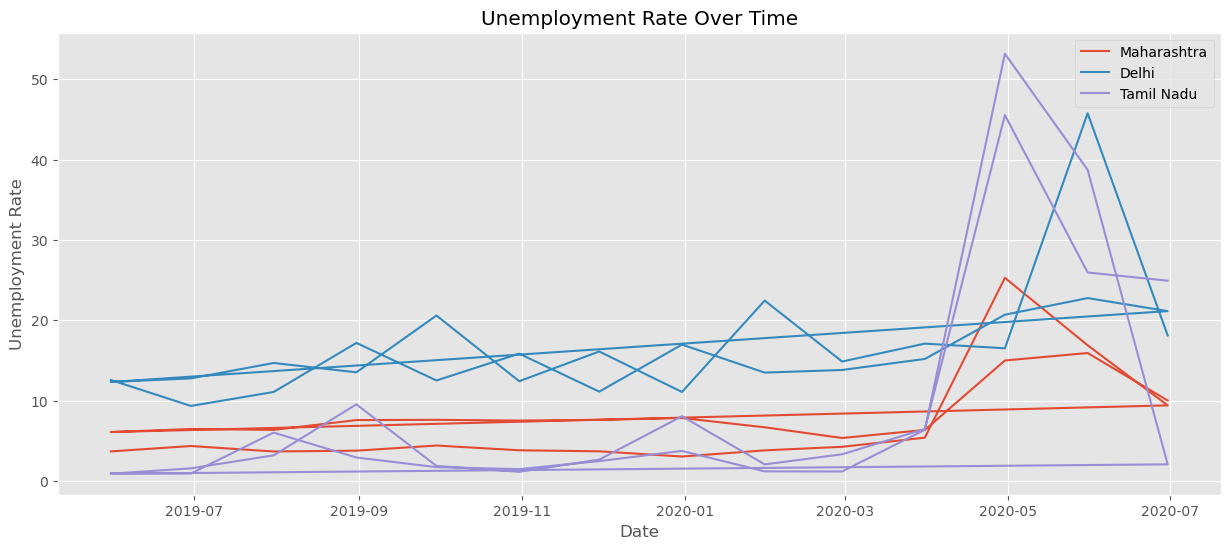

In [32]:
# Cell 19 - Time Series for 3 States

plt.figure(figsize=(15,6))

for state in major_states:
    
    temp = state_df[state_df["Region"] == state]
    
    plt.plot(temp["Date"],
             temp["Estimated Unemployment Rate (%)"],
             label=state)

plt.legend()

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate")

plt.show()

In [33]:
# Markdown

# Observation:

# Each state follows a different unemployment pattern.
# Some states experienced a larger spike during the pandemic period than others.

In [34]:
# Cell 20 - Top 10 States

top10 = (
    df.groupby("Region")
      ["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

C:\Users\bts\AppData\Local\Temp\ipykernel_20192\3735222952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


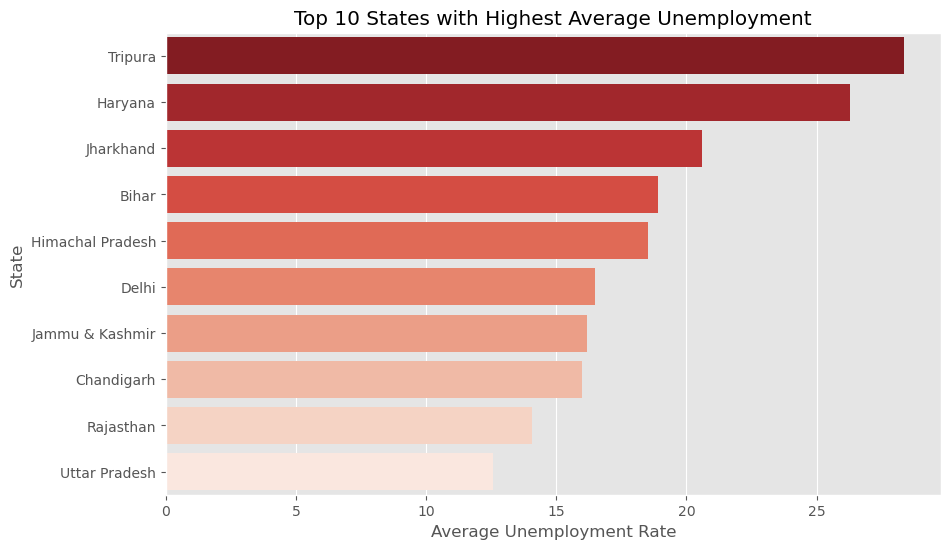

In [35]:
# Cell 21 - Plot Top 10

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Reds_r"
)

plt.title("Top 10 States with Highest Average Unemployment")

plt.xlabel("Average Unemployment Rate")

plt.ylabel("State")

plt.show()

In [36]:
# Markdown

# Observation:

# These states exhibit the highest average unemployment rate across the recorded period.
# Further economic investigation would be needed to determine the causes.

In [37]:
# Cell 22 - Correlation

corr = df[
[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]
].corr()

corr

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


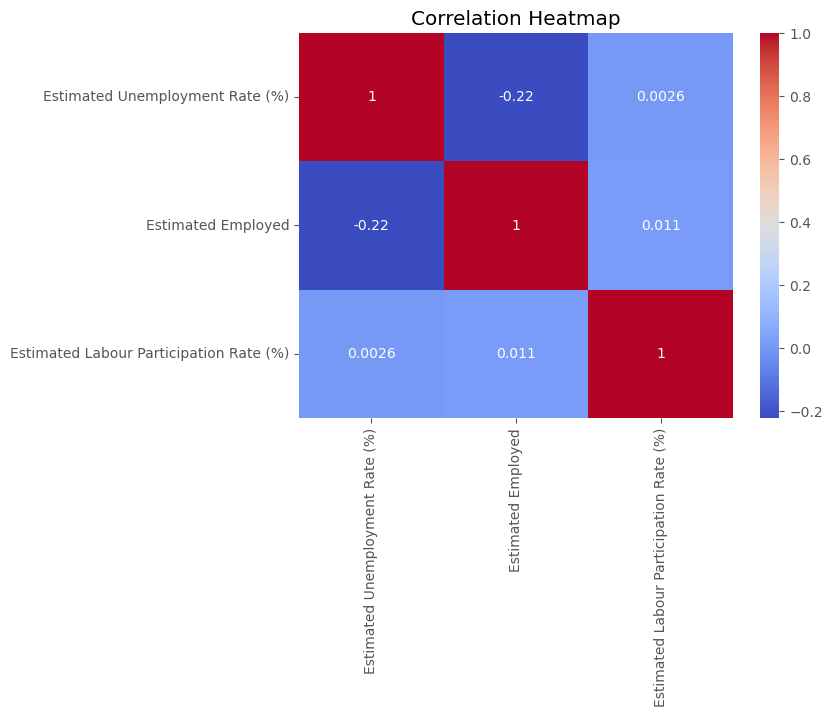

In [38]:
# Cell 23 - Heatmap

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


In [39]:
# Markdown

# Observation:

# The heatmap shows the relationship between unemployment rate,
# employment, and labour participation.
# Positive values indicate direct relationships, while negative values indicate inverse relationships.

In [40]:
# Cell 24 - Pre/Post COVID

covid_date = "2020-03-01"

pre = df[df["Date"] < covid_date]

post = df[df["Date"] >= covid_date]

In [41]:
# Cell 25 - Means

pre_mean = pre["Estimated Unemployment Rate (%)"].mean()

post_mean = post["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID :", pre_mean)

print("Post-COVID :", post_mean)

Pre-COVID : 9.509533582089553
Post-COVID : 17.774362745098042


In [42]:
# Cell 26 - Comparison Chart

comparison = pd.DataFrame({
    "Period":["Pre COVID","Post COVID"],
    "Rate":[pre_mean,post_mean]
})

comparison

,Period,Rate
0,Pre COVID,9.509534
1,Post COVID,17.774363


C:\Users\bts\AppData\Local\Temp\ipykernel_20192\4246502409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


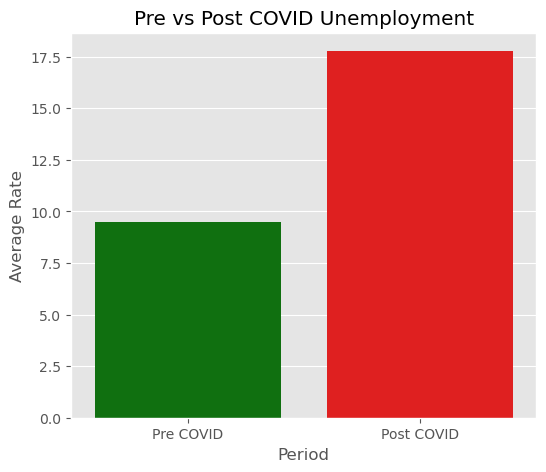

In [43]:
# Cell 27 - Plot

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Rate",
    palette=["green","red"]
)

plt.title("Pre vs Post COVID Unemployment")

plt.ylabel("Average Rate")

plt.show()

In [44]:
# Markdown

# Observation:

# The average unemployment rate increased significantly after the COVID-19 outbreak.
# This reflects the nationwide lockdowns and reduced economic activity during the pandemic.

In [47]:
# Cell 28 - Save Clean Dataset

df.to_csv("clean_unemployment.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [46]:
# # Cell 29 - Final Conclusions (Markdown)

# # Conclusion

# - The unemployment rate varies considerably across Indian states.
# - Several states consistently report higher unemployment than others.
# - Monthly trends reveal noticeable fluctuations over time.
# - A clear increase in unemployment is observed during the COVID-19 period.
# - Correlation analysis provides insight into how unemployment, employment, and labour participation are related.
# - This analysis demonstrates how Python can be used for data cleaning, visualization, and extracting meaningful insights from socio-economic data.